# Summary
- [Methodology and Procedure](#methodology-and-procedure)
- [Fitts' Plots](#fitts-plots)
- [Steering Plots](#steering-plots)
- [Results](#results)
- [Problems](#problems)

# Methodology and Procedure

### **_Fitts' Law_**
For Fitts law a standard layout of 10 Circles was chosen with Targetsizes [30, 55, 80] and Distances (radius) [300, 400, 500]. The last radius was chosen so the circle already goes over the edge of the window to test the border-behaviour of the gesture-input-methods.  
Each combination of conditions was repeated 3times per participant.  
The orientation/Rotation of the cirlces was randomised for each condition. Also the direction the circle to click "wanders" is randomized clockwise vs counterclockwise.
Missclicks were also recorded.  
Participants primed a round by pressing **_S_** to make sure they are ready, then the first circle appeared and on click logged timestamp, etc.  

For the Analysis the movement-time between the single dots was taken and for Missclicks the sum of all missclicks of one iteration were calculated. Then the mean of those values across the 3 iterations was taken.
To compare the different Input-Methods the Througput of the Input-Method was calculated, the complete missclicks, the Ratio of Movement-Time to Missclicks and compared Id to movement time.

### **_Steering Law_**
For Steering Law each combination of conditons was also teste 3 times with a randomized order of conditions. Tunneldistances were [500, 800, 1100] with heights beeing [50, 80, 110].  
Participants primed a round by pressing **_S_** to make sure they are ready, then the real trial starts when a movement across the tunnel entrance is registered and ends when the exit is crossed. During the Mouse-movement event of pyglet is logged. Logging also includes hits to the tunnel walls. The continous logging of hits while outside the tunnel also shows how long/much it was.
  

For the Analysis the movement time across the tunnel was taken and the sum of all wall-hits, then again the mean of those values across the three iterations.
For comparison of Input-Methods I again calculated the Througput, the sum of Hits, the comparison of Movement-Time to Hits and compared Id to movement time.


# Fitts' Plots
Following the Plots for the analysis of Fitts' Law

In [12]:
#Imports
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

fitts_Path = "data/fitts"
steering_Path = "data/steering"

#Notes:
# - Code was created with support of the local gemma-4 26b model (and succesively copied and adapted for the other cells)
#   Mainly the .agg parts

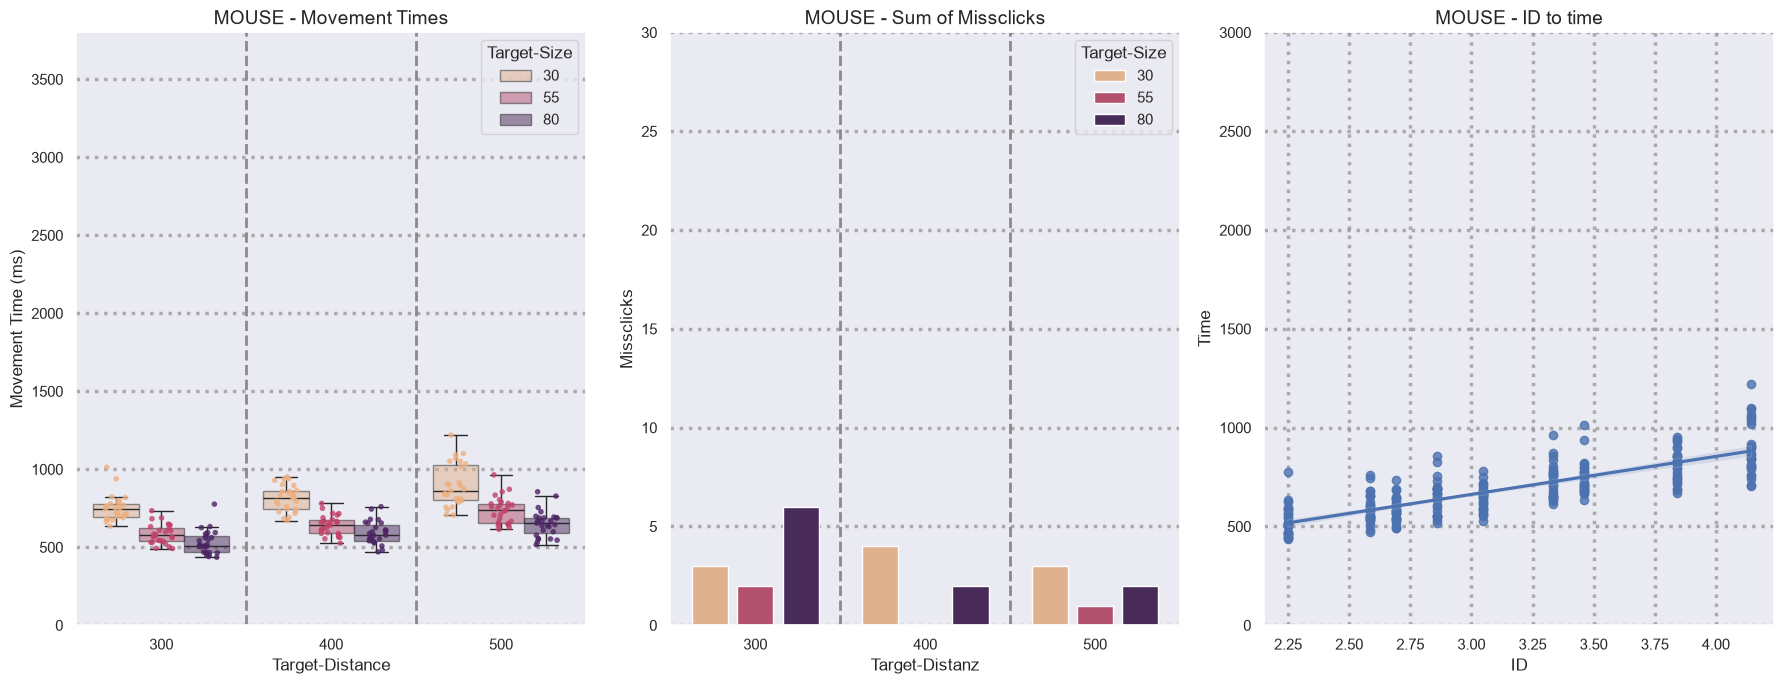

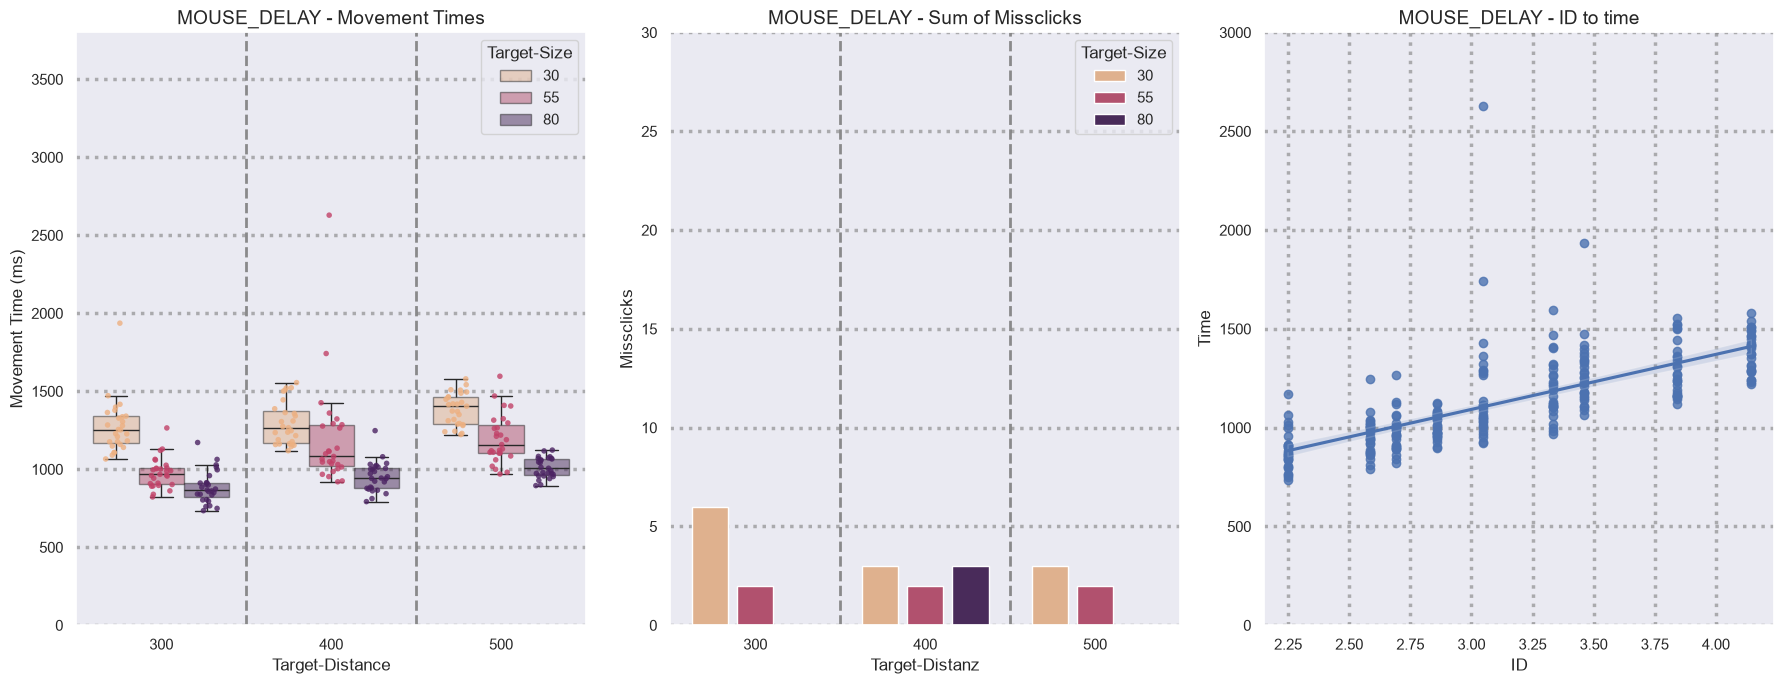

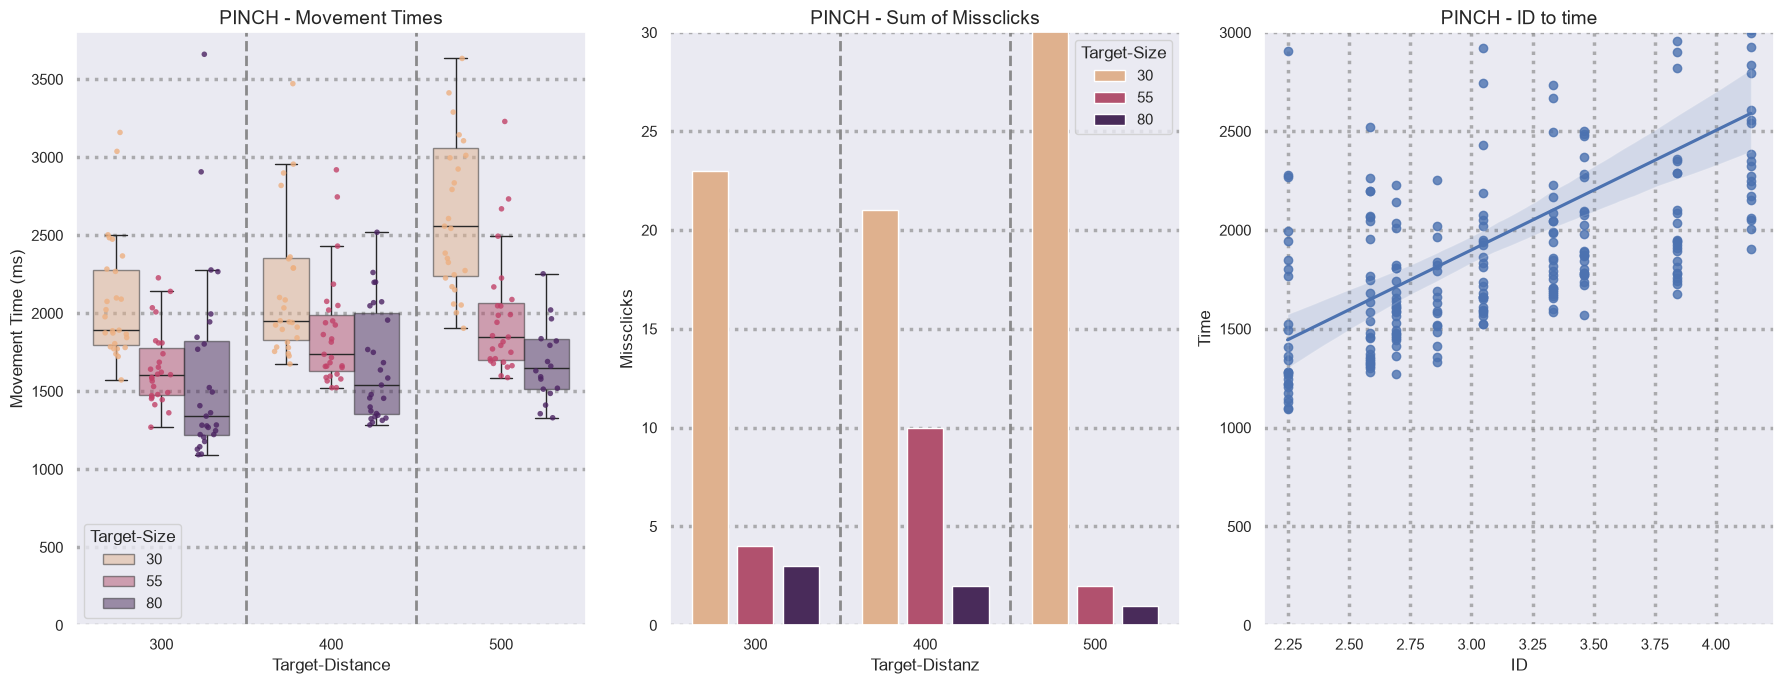

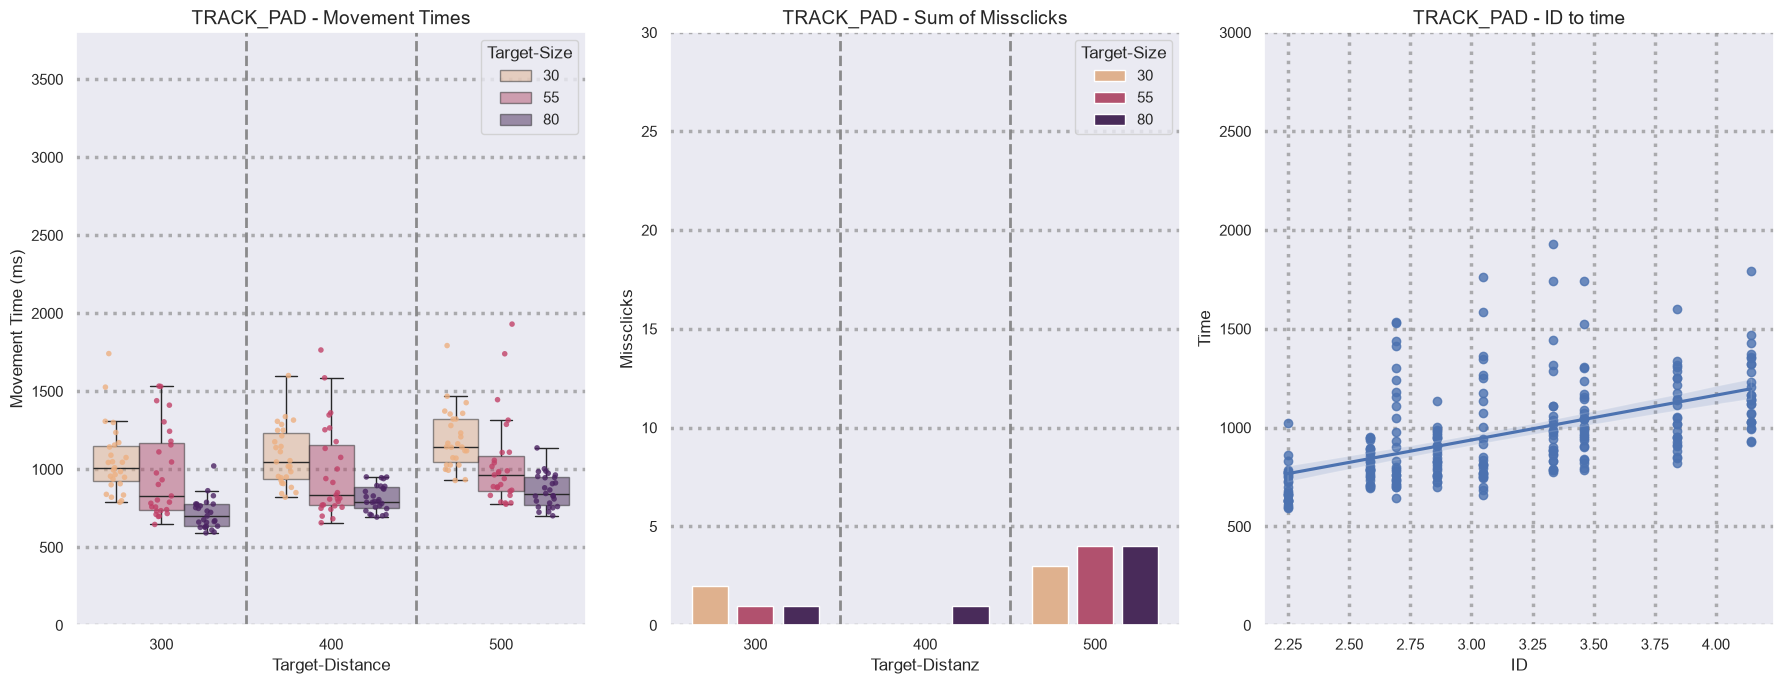

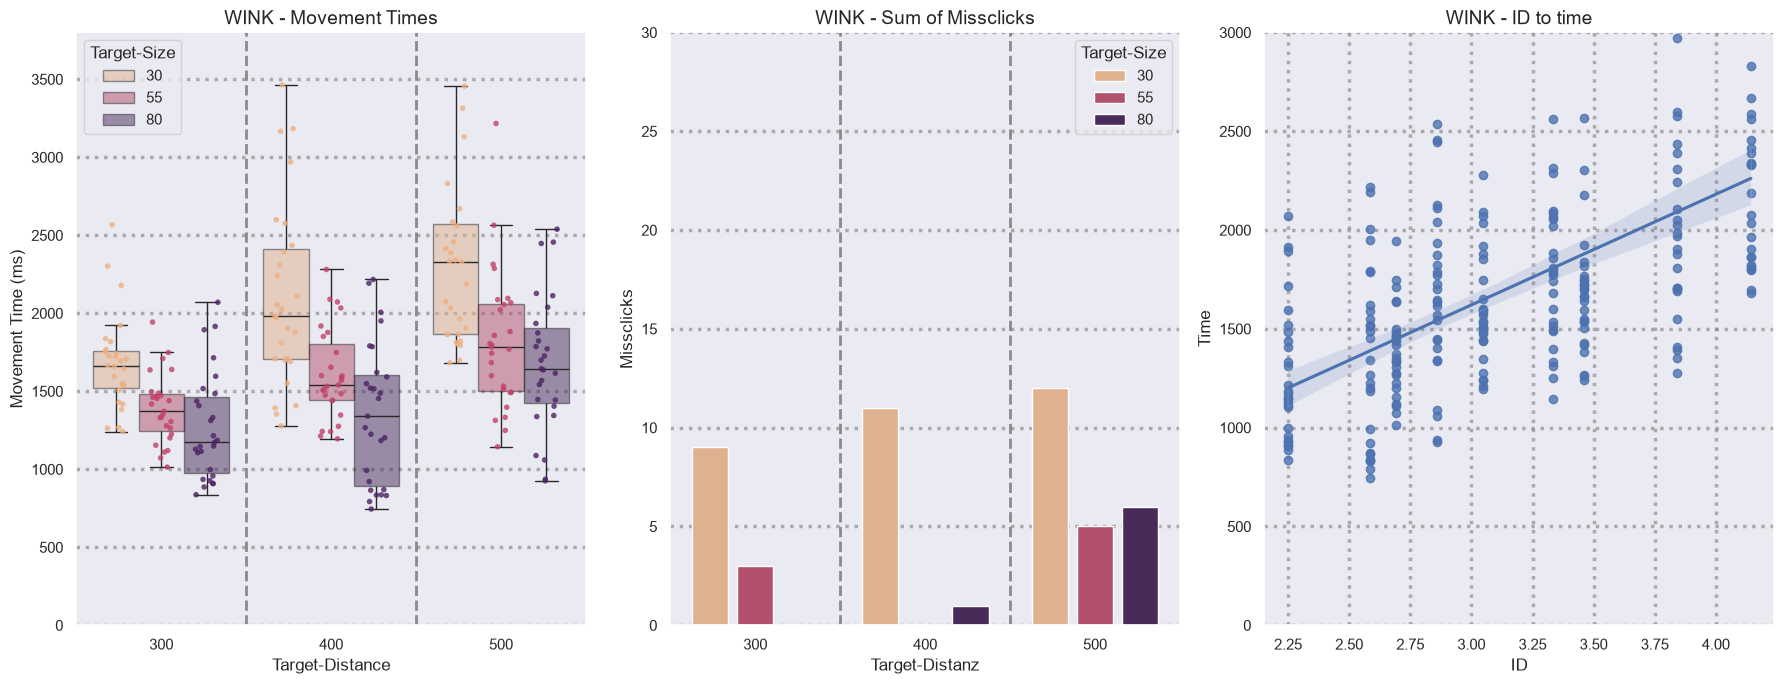

In [13]:
#Code for Input-Methods seperat
def showPlotPerInput(path):
    file_list = glob.glob(f"{path}/fitts_*.csv")
    all_data = []

    for file in file_list:
        df = pd.read_csv(file, sep=";")

        input_name = df["input_mode"][0]

        #seperates the iterations in one file and calculates the diff-time between targetclicks => then drops the first one which can't be calculated due to missing one before (pid could be left out)
        #sets the calculated mt as new column
        df["mt"] = df.groupby(["pid","iteration"])["timestamp"].transform(lambda x: x.diff())
        df = df.dropna(subset=["mt"])

        all_data.append(df)

    sorted_df = pd.concat(all_data, ignore_index=True)

    #Transform Data
    #group all data by the differrent variables and calculate the mean of mt for them (shrinks the data to mean per targetclick so for 3 persons there should be 27points per condition/9 per person(e.g. width=30,distance=300), so times 9 for each condition should be 243 points total)
    user_target_df = (
        sorted_df.groupby(["pid", "target_d", "target_w", "target_id"])["mt"]
        .mean()
        .reset_index()
    )

    #calculates Index of Difficulty per movement of mean iterations
    ID_df = (
        sorted_df.groupby(["pid", "target_d", "target_w", "target_id"])["mt"]
        .mean()
        .reset_index()
    )
    ID_df["ID"] = np.log2((ID_df["target_d"] / ID_df["target_w"]) + 1)

    #groups by condition and calculates the absolut sum of missclicks for the condition (independent of participants and iterations)
    missclicks_sum_df = (
        sorted_df.groupby(["target_d", "target_w"])["miss_clicks"]
        .sum()
        .reset_index()
    )
    
    #Plots
    sns.set_theme(style="darkgrid", rc={"grid.linewidth": 2.5})
    fig, axes = plt.subplots(1, 3, figsize=(18, 7))

    #Movement-Time
    axes[0].grid(True, linestyle=":", alpha=0.6, color="gray", zorder=0)
    sns.boxplot(
        ax=axes[0],
        data=user_target_df,
        x="target_d",
        y="mt",
        hue="target_w",
        palette="flare",
        showfliers=False,
        boxprops=dict(alpha=0.5, zorder=2),
    )
    sns.stripplot(
        ax=axes[0],
        data=user_target_df,
        x="target_d",
        y="mt",
        hue="target_w",
        palette="flare",
        alpha=0.8,
        size=4,  
        jitter=0.2,
        dodge=True,
        legend=False,
        zorder=3,
    )

    #seperators were also genrated with help of gemma-4 26b
    for i in range(len(missclicks_sum_df["target_d"].unique()) - 1):
        axes[0].axvline(
            x=i + 0.5, color="gray", linestyle="--", alpha=0.9, linewidth=2
        )

    axes[0].set_title(f"{input_name} - Movement Times",fontsize=14)
    axes[0].set_xlabel("Target-Distance", fontsize=12)
    axes[0].set_ylabel("Movement Time (ms)", fontsize=12)
    axes[0].set_ylim(0,3800)
    axes[0].legend(title="Target-Size", fontsize=11)

    #Missclicks
    axes[1].grid(True, linestyle=":", alpha=0.6, color="gray", zorder=0)

    sns.barplot(
        ax=axes[1],
        data=missclicks_sum_df,
        x="target_d",
        y="miss_clicks",
        hue="target_w",
        palette="flare",
        gap=0.2,
        zorder=2,  
    )
    for i in range(len(missclicks_sum_df["target_d"].unique()) - 1):
        axes[1].axvline(
            x=i + 0.5, color="gray", linestyle="--", alpha=0.9, linewidth=2
        )

    axes[1].set_title(f"{input_name} - Sum of Missclicks",fontsize=14,)
    axes[1].set_xlabel("Target-Distanz", fontsize=12)
    axes[1].set_ylabel("Missclicks", fontsize=12)
    axes[1].set_ylim(0,30)
    axes[1].legend(title="Target-Size", fontsize=11)

    axes[2].grid(True, linestyle=":", alpha=0.6, color="gray", zorder=0)
    sns.regplot(
        ax=axes[2],
        data=ID_df,
        x="ID",
        y="mt",
        scatter=True,
        ci=95
    )

    axes[2].set_title(f"{input_name} - ID to time", fontsize=14)
    axes[2].set_xlabel("ID", fontsize=12)
    axes[2].set_ylabel("Time", fontsize=12)
    axes[2].set_ylim(0,3000)

    plt.tight_layout()
    plt.show()


for file in os.listdir(fitts_Path):
    path = f"{fitts_Path}/{file}"
    if os.path.isdir(path): 
        showPlotPerInput(path)

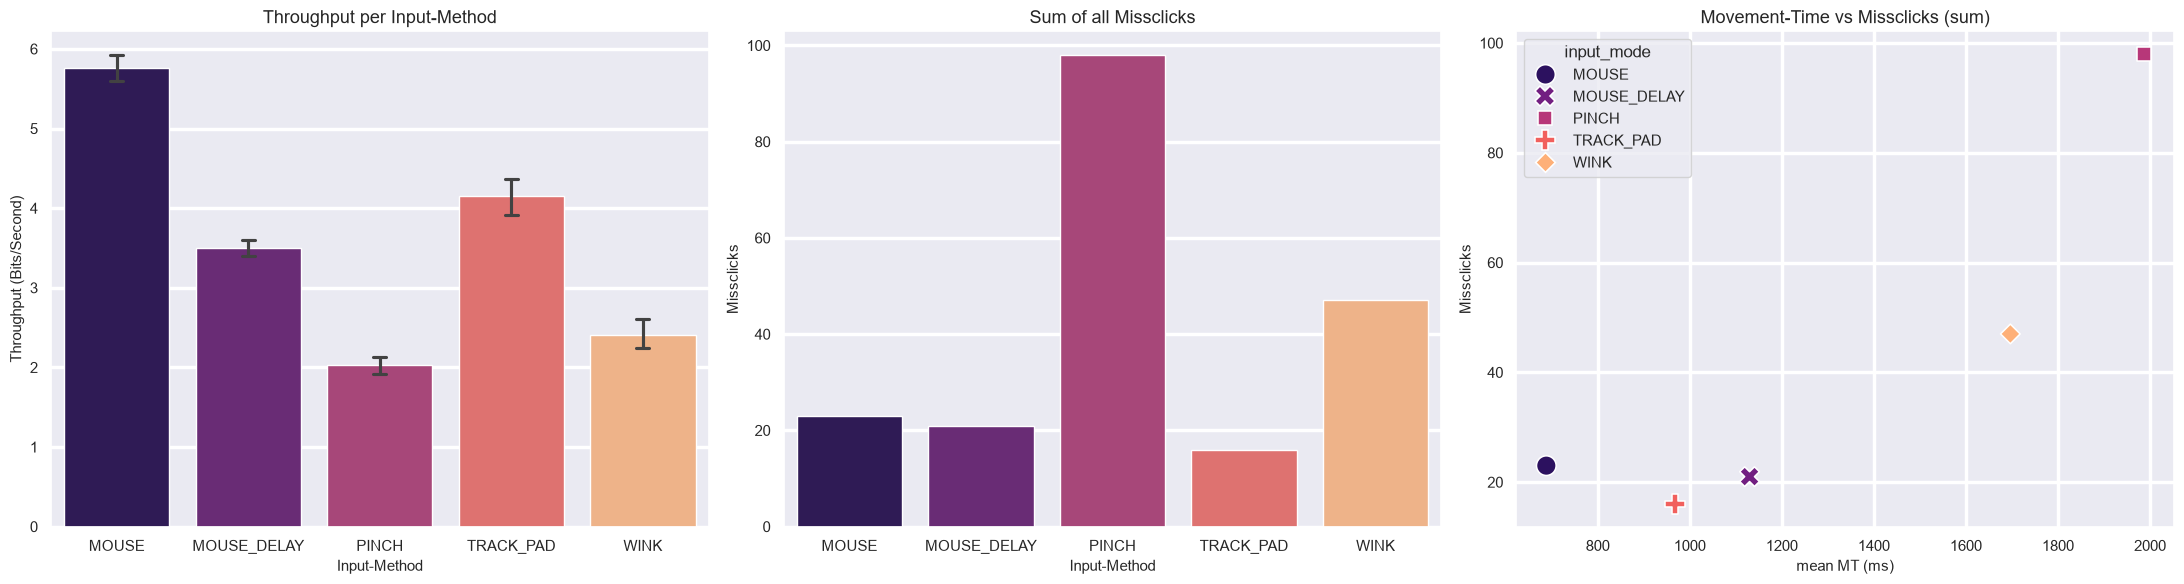

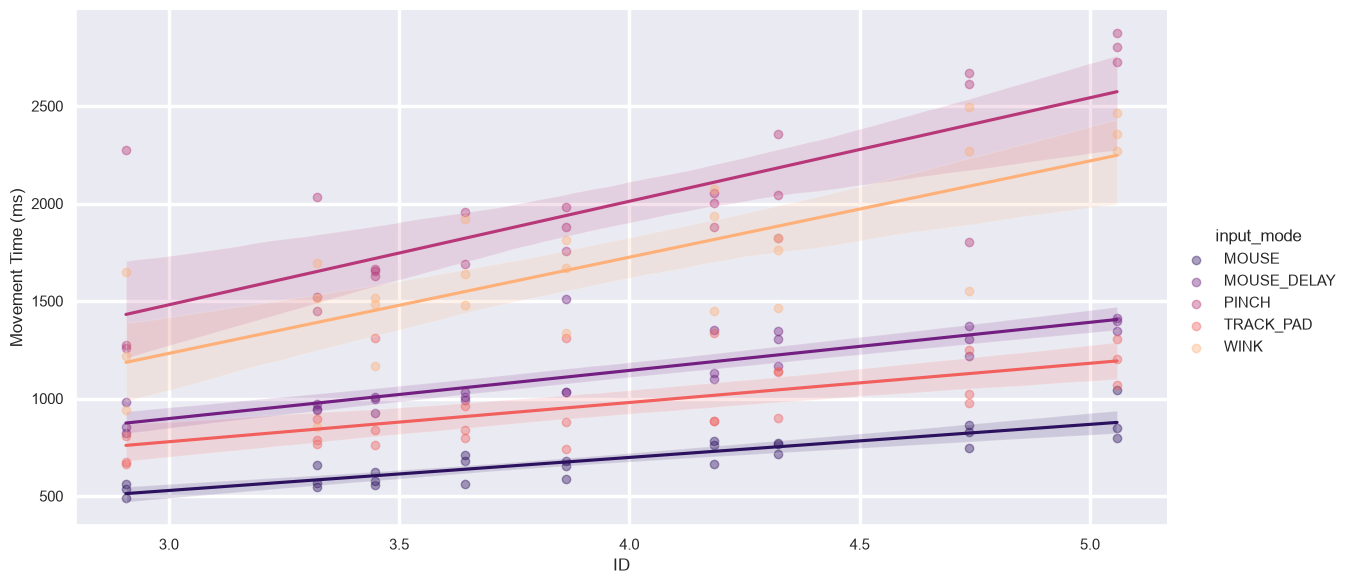

In [14]:
#Code for Comparison of Input-Methods
file_list = glob.glob(f"{fitts_Path}/**/*.csv", recursive=True)
all_data = []

for file in file_list:
    df = pd.read_csv(file, sep=";")
    
    df["mt"] = df.groupby(["pid", "iteration"])["timestamp"].transform(
        lambda x: x.diff()
    )
    df = df.dropna(subset=["mt"])
    all_data.append(df)

sorted_df = pd.concat(all_data, ignore_index=True)
sorted_df["ID"] = np.log2((2 * sorted_df["target_d"]) / sorted_df["target_w"])

#Especially here gemma-4 helped alot
#groups by conditions and calculates mt and missclicks for each group
input_summary = (
    sorted_df.groupby(["input_mode", "pid", "target_d", "target_w", "ID"])
    .agg(mt=("mt", "mean"), miss_clicks=("miss_clicks", "sum"))
    .reset_index()
)

#Then calculates the thoughput per group and sum of all misclicks per input method
input_summary["throughput"] = (input_summary["ID"] / input_summary["mt"]) * 1000
absolute_missclicks = (sorted_df.groupby("input_mode")["miss_clicks"].sum().reset_index())

sns.set_theme(style="darkgrid", rc={"grid.linewidth": 2.5})
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

#seaborn automatically calculates the mean of the groups
sns.barplot(
    ax=axes[0],
    data=input_summary,
    x="input_mode",
    y="throughput",
    palette="magma",
    hue="input_mode",
    capsize=0.1,
)
axes[0].set_title("Throughput per Input-Method", fontsize=13)
axes[0].set_xlabel("Input-Method", fontsize=11)
axes[0].set_ylabel("Throughput (Bits/Second)", fontsize=11)

sns.barplot(
    ax=axes[1],
    data=absolute_missclicks,
    x="input_mode",
    y="miss_clicks",
    palette="magma",
    hue="input_mode",
    #estimator=np.sum,
    #capsize=0.1
)
axes[1].set_title("Sum of all Missclicks", fontsize=13)
axes[1].set_xlabel("Input-Method", fontsize=11)
axes[1].set_ylabel("Missclicks", fontsize=11)

#gets only the mean/sum of all movementtimes and missclicks for the input-methods 
vs_data = (
    input_summary.groupby("input_mode")
    .agg(mean_mt=("mt", "mean"), total_misses=("miss_clicks", "sum"))
    .reset_index()
)

sns.scatterplot(
    ax=axes[2],
    data=vs_data,
    x="mean_mt",
    y="total_misses",
    hue="input_mode",
    style="input_mode",
    palette="magma",
    s=200,
)
axes[2].set_title("Movement-Time vs Missclicks (sum)", fontsize=13)
axes[2].set_xlabel("mean MT (ms)", fontsize=11)
axes[2].set_ylabel("Missclicks", fontsize=11)

plt.tight_layout()
plt.show()

#Code generated by Gemini (just asked how to get different hue per inputdevice for regplot (first suggested a loop, then after some more inquires suggested this))
g = sns.lmplot(
    data=input_summary,
    x="ID",
    y="mt",
    hue="input_mode",
    palette="magma",
    height=6,
    aspect=2,
    scatter_kws={"alpha": 0.4}
)
g.set_axis_labels("ID", "Movement Time (ms)")
plt.show()

# Steering Plots
Following the Plots for the analysis of Steering Law

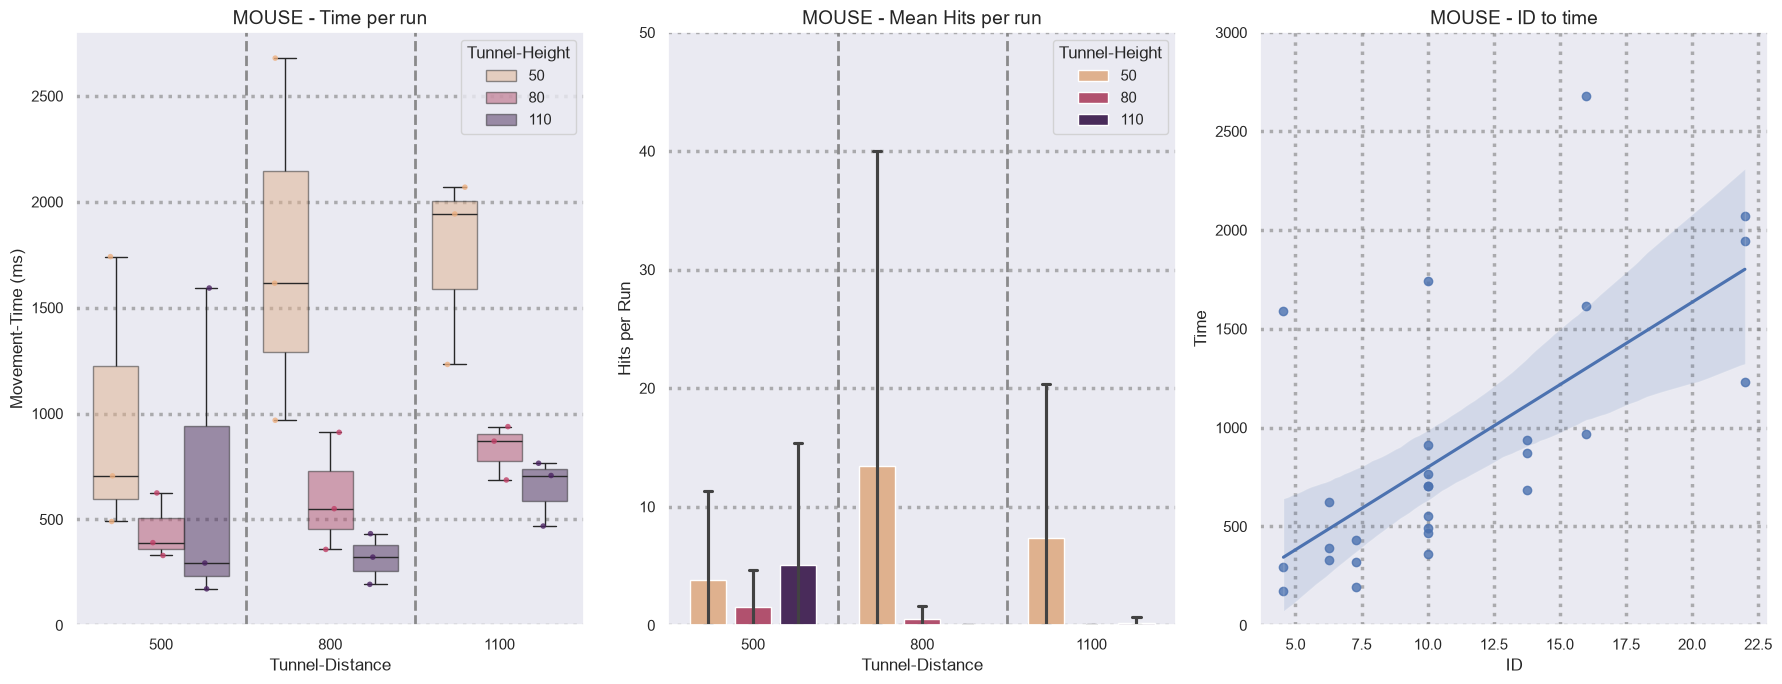

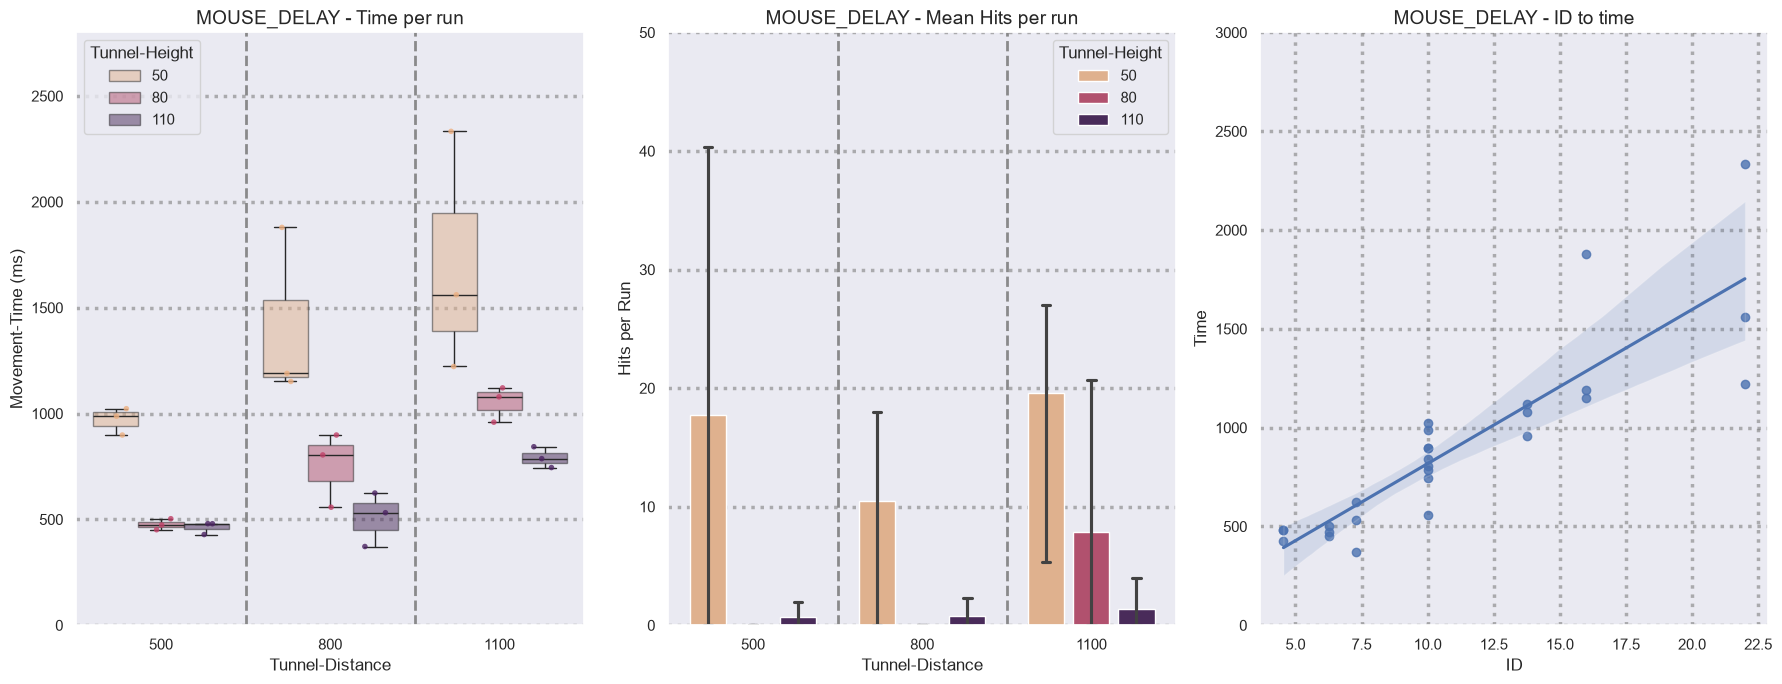

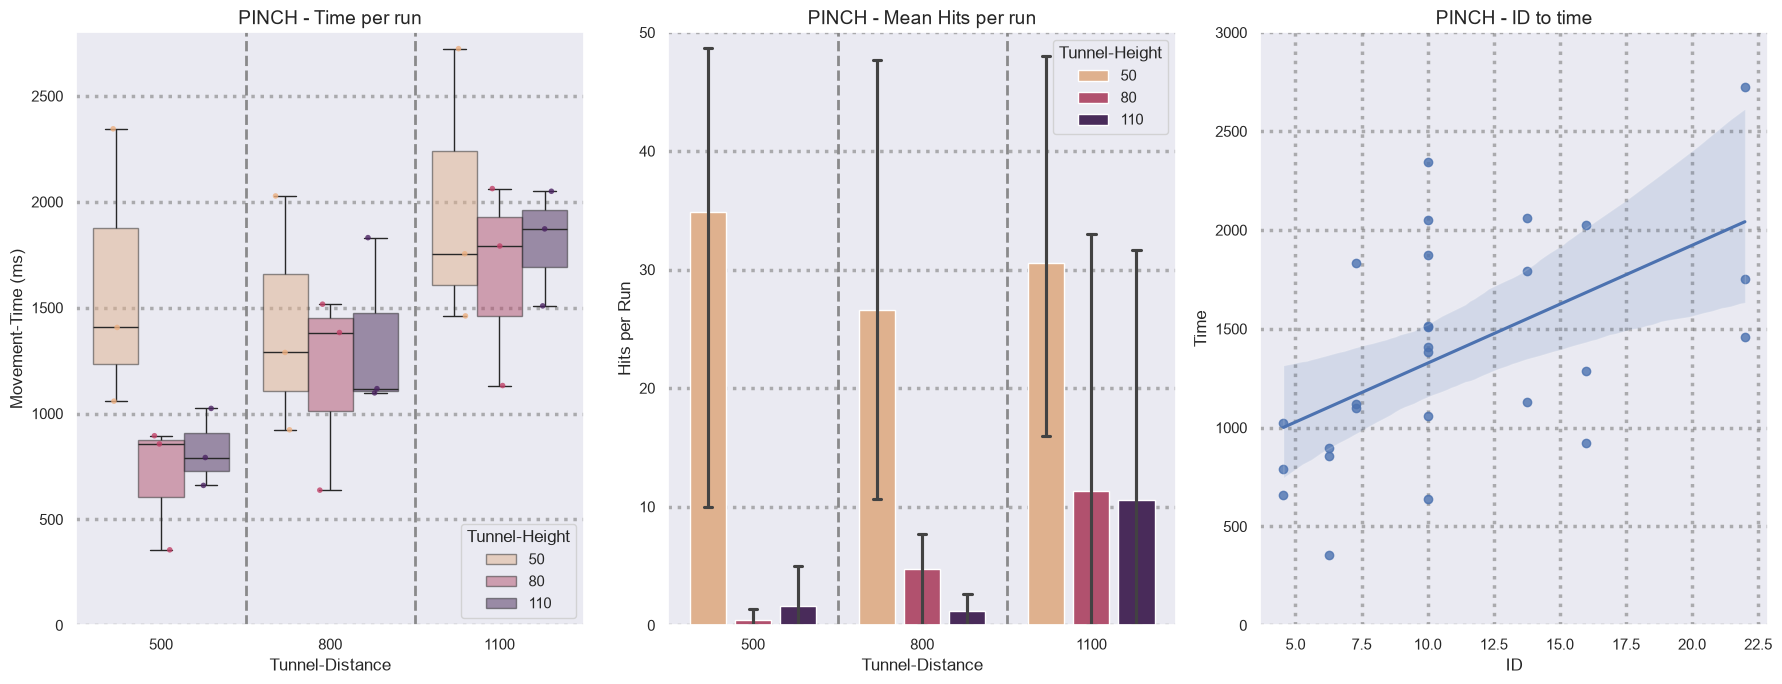

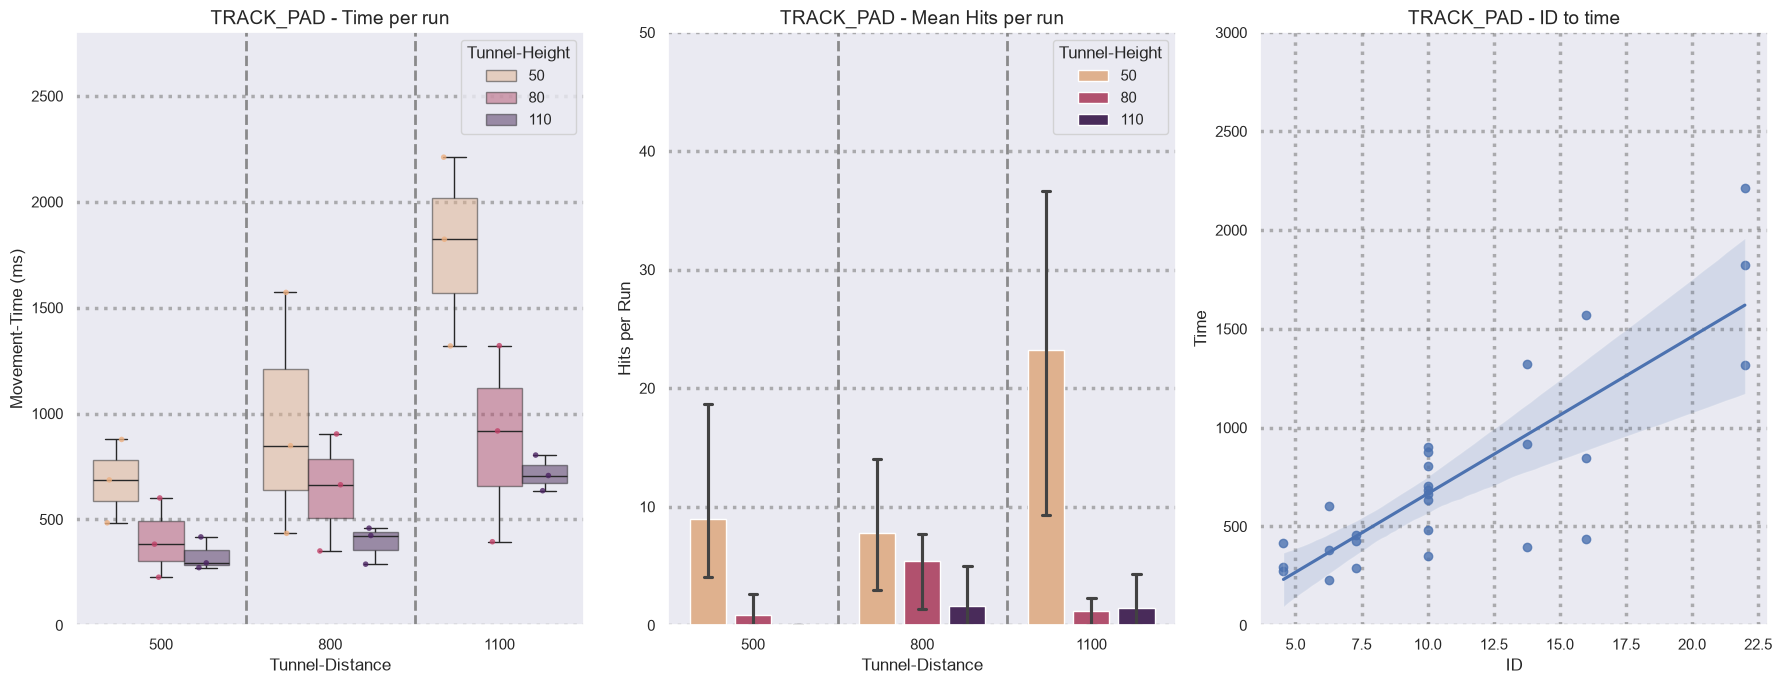

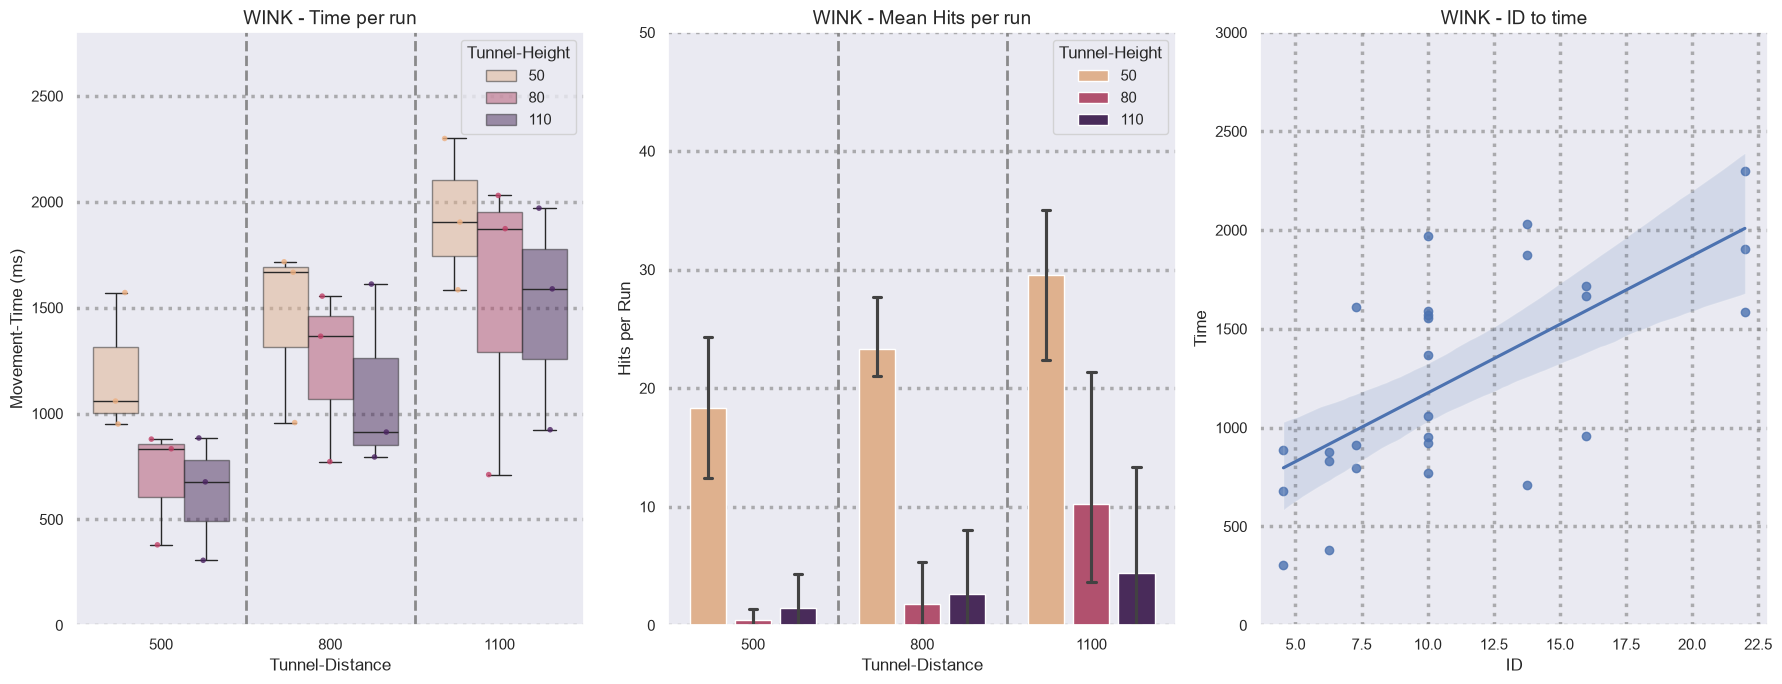

In [15]:
#Code for Input-Methods seperat
def showPlotPerInput(path):
    file_list = glob.glob(f"{path}/*.csv")
    all_data = []

    for file in file_list:
        df = pd.read_csv(file, sep=";")

        input_name = df["input_mode"][0]
        
        #instead of difference between each datapoint it's difference between first and last timestamp = total movementtime
        #for each file groups by pId and iteration and calculates difference between latest and earliest timestamp
        iteration_time = (
            df.groupby(["pid", "iteration"])["timestamp"]
            .agg(lambda x: (x.max() - x.min()))
            .reset_index()
        )

        #same but sum of hits
        iteration_hits = (
            df.groupby(["pid", "iteration"])["hit"].sum().reset_index()
        )

        #and add the specific conditions (is always same so just first)
        conditions = (
            df.groupby(["pid", "iteration"])[["tunnel_w", "tunnel_h"]]
            .first()
            .reset_index()
        )

        #then merge all into one table
        merged = pd.merge(iteration_time, iteration_hits, on=["pid", "iteration"])
        merged = pd.merge(merged, conditions, on=["pid", "iteration"])

        all_data.append(merged)

    sorted_df = pd.concat(all_data, ignore_index=True)

    user_target_df = (
        sorted_df.groupby(["pid", "tunnel_w", "tunnel_h"])["timestamp"]
        .mean()
        .reset_index()
    )

    ID_df = (
        sorted_df.groupby(["pid", "tunnel_w", "tunnel_h"])["timestamp"]
        .mean()
        .reset_index()
    )
    ID_df["ID"] = ID_df["tunnel_w"] / ID_df["tunnel_h"]

    user_errors_df = (
        sorted_df.groupby(["pid", "tunnel_w", "tunnel_h"])["hit"]
        .mean()
        .reset_index()
    )

    sns.set_theme(style="darkgrid", rc={"grid.linewidth": 2.5})
    fig, axes = plt.subplots(1, 3, figsize=(18, 7))

    axes[0].grid(True, linestyle=":", alpha=0.6, color="gray", zorder=0)
    sns.boxplot(
        ax=axes[0],
        data=user_target_df,
        x="tunnel_w",
        y="timestamp",
        hue="tunnel_h",
        palette="flare",
        showfliers=False,
        boxprops=dict(alpha=0.5, zorder=2),
    )
    sns.stripplot(
        ax=axes[0],
        data=user_target_df,
        x="tunnel_w",
        y="timestamp",
        hue="tunnel_h",
        palette="flare",
        alpha=0.8,
        size=4,
        jitter=0.2,
        dodge=True,
        legend=False,
        zorder=3,
    )
    for i in range(len(user_errors_df["tunnel_w"].unique()) - 1):
        axes[0].axvline(
            x=i + 0.5, color="gray", linestyle="--", alpha=0.9, linewidth=2
        )

    
    axes[0].set_title(f"{input_name} - Time per run", fontsize=14)
    axes[0].set_xlabel("Tunnel-Distance", fontsize=12)
    axes[0].set_ylabel("Movement-Time (ms)", fontsize=12)
    axes[0].set_ylim(0, 2800)
    axes[0].legend(title="Tunnel-Height", fontsize=11)

    axes[1].grid(True, linestyle=":", alpha=0.6, color="gray", zorder=0)
    sns.barplot(
        ax=axes[1],
        data=user_errors_df, 
        x="tunnel_w",
        y="hit",
        hue="tunnel_h",
        palette="flare",
        gap=0.2,
        capsize=0.15,
        zorder=2,
    )
    for i in range(len(user_errors_df["tunnel_w"].unique()) - 1):
        axes[1].axvline(
            x=i + 0.5, color="gray", linestyle="--", alpha=0.9, linewidth=2
        )

    axes[1].set_title(f"{input_name} - Mean Hits per run", fontsize=14)
    axes[1].set_xlabel("Tunnel-Distance", fontsize=12)
    axes[1].set_ylabel("Hits per Run", fontsize=12)
    axes[1].set_ylim(0,50)
    axes[1].legend(title="Tunnel-Height", fontsize=11)

    
    axes[2].grid(True, linestyle=":", alpha=0.6, color="gray", zorder=0)
    sns.regplot(
        ax=axes[2],
        data=ID_df,
        x="ID",
        y="timestamp",
        scatter=True,
        ci=95
    )

    axes[2].set_title(f"{input_name} - ID to time", fontsize=14)
    axes[2].set_xlabel("ID", fontsize=12)
    axes[2].set_ylabel("Time", fontsize=12)
    axes[2].set_ylim(0,3000)

    plt.tight_layout()
    plt.show()

if os.path.exists(steering_Path):
    for file in os.listdir(steering_Path):
        path = f"{steering_Path}/{file}"
        if os.path.isdir(path):
            showPlotPerInput(path)


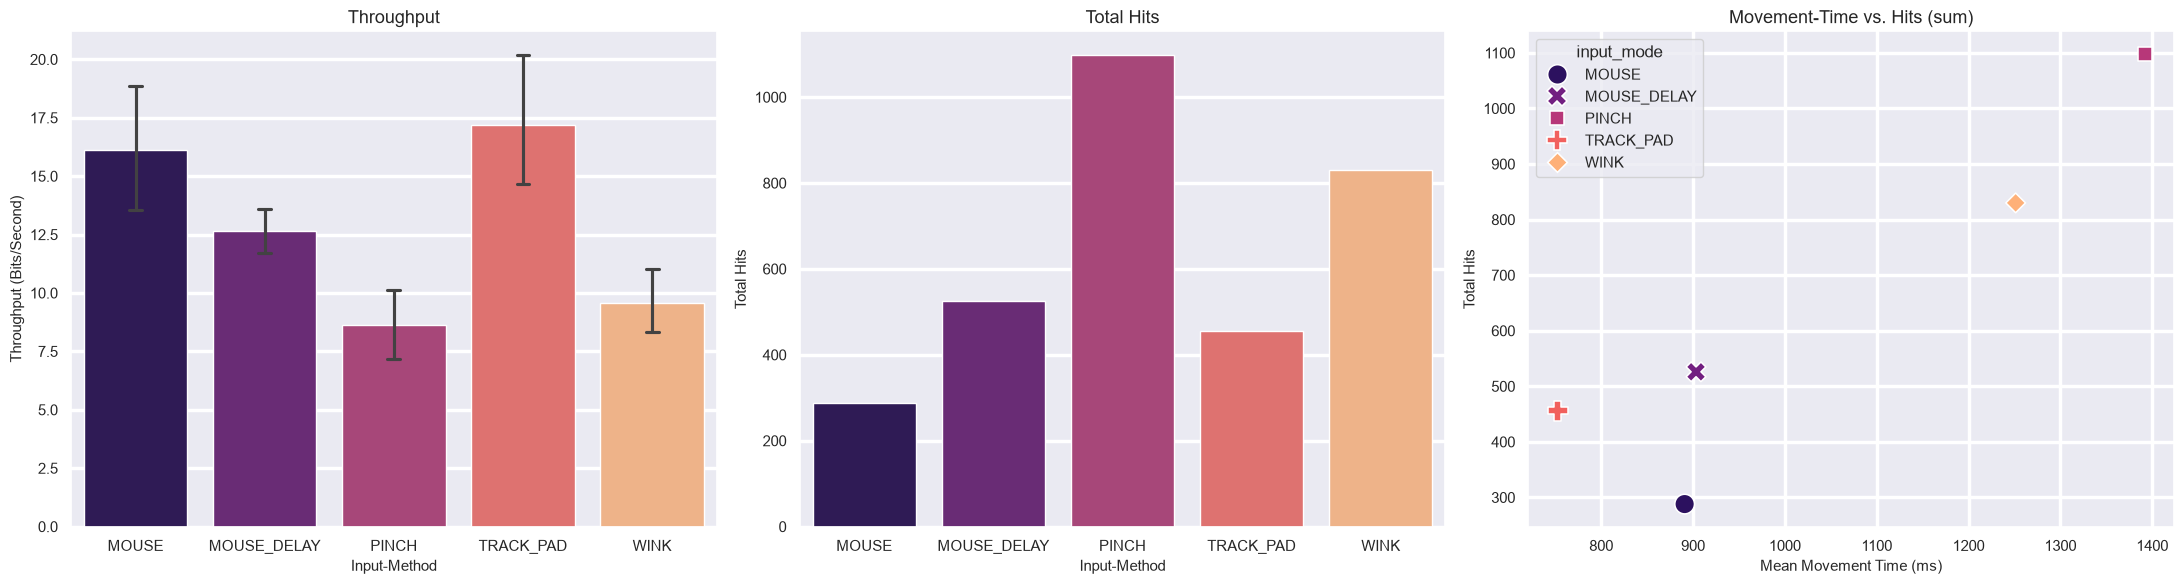

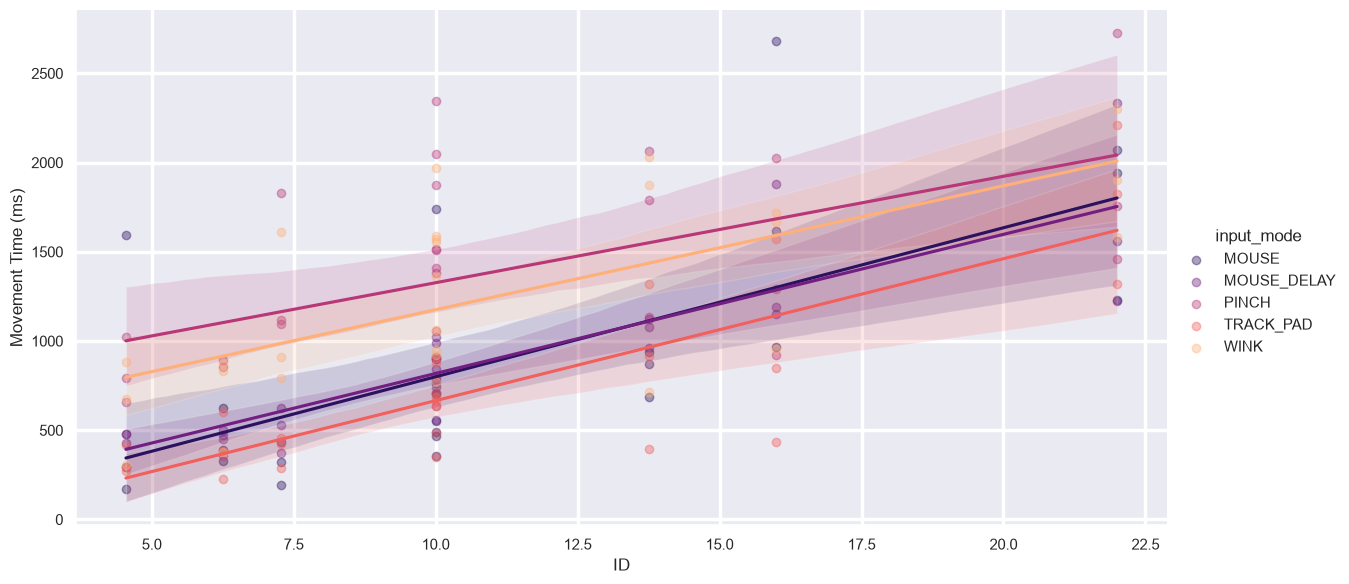

In [16]:
#Code for Comparison of Input-Methods
file_list = glob.glob(f"{steering_Path}/**/*.csv", recursive=True)
all_data = []

for file in file_list:
        df = pd.read_csv(file, sep=";")

        input_name = df["input_mode"][0]
        
        #instead of difference between each datapoint it's difference between first and last timestamp = total movementtime
        #for each file groups by pId and iteration and calculates difference between latest and earliest timestamp
        iteration_time = (
            df.groupby(["pid", "iteration"])["timestamp"]
            .agg(lambda x: (x.max() - x.min()))
            .reset_index()
        )

        #same but sum of hits
        iteration_hits = (
            df.groupby(["pid", "iteration"])["hit"].sum().reset_index()
        )

        #and add the specific conditions (is always same so just first)
        conditions = (
            df.groupby(["pid", "iteration"])[["input_mode","tunnel_w", "tunnel_h"]]
            .first()
            .reset_index()
        )

        #then merge all into one table
        merged = pd.merge(iteration_time, iteration_hits, on=["pid", "iteration"])
        merged = pd.merge(merged, conditions, on=["pid", "iteration"])

        all_data.append(merged)


sorted_df = pd.concat(all_data, ignore_index=True)
sorted_df["ID"] = sorted_df["tunnel_w"] / sorted_df["tunnel_h"]

input_summary = (
    sorted_df.groupby(["input_mode", "pid", "tunnel_w", "tunnel_h", "ID"])
    .agg(mt=("timestamp", "mean"), hits=("hit", "sum"))
    .reset_index()
)
input_summary["throughput"] = (input_summary["ID"] / input_summary["mt"]) * 1000

total_hits = (
    sorted_df.groupby("input_mode")["hit"].sum().reset_index()
)

sns.set_theme(style="darkgrid", rc={"grid.linewidth": 2.5})
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.barplot(
    ax=axes[0],
    data=input_summary,
    x="input_mode",
    y="throughput",
    palette="magma",
    hue="input_mode",
    capsize=0.1,
)
axes[0].set_title("Throughput", fontsize=13)
axes[0].set_xlabel("Input-Method", fontsize=11)
axes[0].set_ylabel("Throughput (Bits/Second)", fontsize=11)

sns.barplot(
    ax=axes[1],
    data=total_hits,
    x="input_mode",
    y="hit",
    palette="magma",
    hue="input_mode",
)
axes[1].set_title("Total Hits", fontsize=13)
axes[1].set_xlabel("Input-Method", fontsize=11)
axes[1].set_ylabel("Total Hits", fontsize=11)

scatter_data = (
    input_summary.groupby("input_mode")
    .agg(mean_mt=("mt", "mean"), total_misses=("hits", "sum"))
    .reset_index()
)

sns.scatterplot(
    ax=axes[2],
    data=scatter_data,
    x="mean_mt",
    y="total_misses",
    hue="input_mode",
    style="input_mode",
    palette="magma",
    s=200,
)
axes[2].set_title("Movement-Time vs. Hits (sum)", fontsize=13)
axes[2].set_xlabel("Mean Movement Time (ms)", fontsize=11)
axes[2].set_ylabel("Total Hits", fontsize=11)

plt.tight_layout()
plt.show()

#Code generated by Gemini (just asked how to get different hue per inputdevice for regplot (first suggested a loop, then after some more inquires suggested this))
g = sns.lmplot(
    data=input_summary,
    x="ID",
    y="mt",
    hue="input_mode",
    palette="magma",
    height=6,
    aspect=2,
    scatter_kws={"alpha": 0.4}
)
g.set_axis_labels("ID", "Movement Time (ms)")
plt.show()

# **Results**
>**Note:**  
 *Gave Gemini my finished text and prompted: "Can you please only correct spelling, grammar, nothing else, no rewrites!!!"*

 **The results were written with only 2 participants...luckily adding my own third data didn't change much...**
___

## **Fitts' Law**
For better comparison:  
- set ylim of movement-times to 3800
- set ylim of misclicks to 30
- set ylim of ID vs mt to 3000

#### **_Single-Plots_**
- **Mouse:**   
    The Mouse had surprisingly more misclicks for the bigger and closer targets, due to overconfidence, since participants did it really fast and overshot at times.
    The ID to mt increases pretty linearly with a small incline and a pretty slim confidence interval.
- **Mouse_delay:**  
    Interestingly, the Mouse had a bigger increase in movement times than even the 150ms of latency.
    And fewer misclicks, which can be explained by a more careful approach by the participants.  
    ID to mt is the same as Mouse, just with a larger movement-time.
- **Pinch:**  
    Pinch was the slowest and most inaccurate input method. The times also spread the most.
    Especially for the very small targets, the time increased significantly, which is also explained by the huge amount of misclicks.  
    ID to mt has a sharp incline and pretty bad confidence.
- **Wink:**  
    For Wink, the target size was also more significant than the distance between targets, but misclicks improved a lot in comparison to Pinch.
    The ID to mt is pretty similar to Pinch, with a faster mt and a little flatter incline.
- **Trackpad:**  
    For the trackpad, the distance of the targets remarkably didn't really matter and misclicks were the least of all input methods, which could be explained by the again more careful approach paired with a predictable (in comparison to delay) pointer. 
    The ID to mt settles between the mouse and mouse with delay with a similar incline and confidence. 

Generally, the distance didn't have as much of an impact as previously thought. 


#### **_Throughput_**
Unsurprisingly, the Mouse is still the best input device by throughput.
But interestingly, the mouse with delay was worse than the trackpad, even though participants reported getting used to the delay at the end and almost not feeling it anymore. So a second round or a longer warmup could improve the results.  
For gesture-based input, the Wink as a click surpassed the Pinch of thumb and index finger.

#### **_Misclicks_**
For misclicks, the Trackpad actually got the best result, followed by the delay.
One explanation/observation was that with more delay or the lower accuracy of the trackpad, participants were more careful navigating and as a result made fewer mistakes. That also shows on the plain Mouse with big targets, since the participants got "overconfident" and often were so fast they overshot.
The Wink was a lot better than the Pinch, which got twice as many misclicks.

#### **_Time vs Misclicks_**
The Mouse was the fastest with a few misclicks, while Delay and Trackpad are pretty close in both regards.
The Wink was both faster and less error-prone in comparison to the Pinch.

#### **_ID vs mt_**
The direct comparison shows the results pretty well, with the delay having an ever so slightly higher incline than the trackpad.  
It also shows really well how the gestures become more unreliable faster, with Wink being close to the trackpad and delay at the start.

#### **_Thoughts_**
The Mouse is the clear winner, though it had a few more misclicks, the massively faster speed works in its favor.  
The Delay and Trackpad are pretty close in all regards, with the Trackpad having a slight edge over the delayed mouse.
For gesture input, the Wink is the favored method. The main explanation is that since the pointer is reliant on the middle of the two pinching fingers, it needs some time getting used to, but is still prone to small movements. It did, however, improve with longer usage.  
The pointing via the sole index finger was a lot more accurate and intuitive, and also didn't result in as much fatigue as the pinching.

---

## **Steering Law**
For better comparison:  
- set ylim of movement-times to 2800
- set ylim of hits to 50
- set ylim of ID vs mt to 3000

#### **_Single-Plots_**
- **Mouse**:  
    I can't really explain the big difference in movement times for the mouse; my best guess is the usage of a subpar mouse by the external participant, which he got more used to when reaching the 1100 distance.
    That could also explain the difference in hits, where I had 0 hits and he had a lot more. (We didn't have an alternate, better mouse available at the time.)  
- **Mouse_delay**:  
    These results are more like what was expected, with tunnel distance and height increasing movement time.
    The times of participants were also really similar to each other, with the exception of the 50 height.
- **Pinch**:  
    For Pinch, it was remarkable that the medium height actually was constantly faster than the big height. It could be explained again by overconfidence and the way the movement via gesture works, since it can skip pixels when moved very fast. I checked the code, but all seems right.
    Hits again were the most here, especially for the small height and surprisingly most for the short tunnel, again most likely due to overconfidence and overshooting.  
- **Wink**:  
    For Wink, the pattern of Pinch repeats, but with overall faster movement and fewer hits.  
- **Trackpad**:  
    For the Trackpad, the unproportionally increased time for the 1100 width tunnel can be explained since participants often had to readjust their finger to get through the whole tunnel (remove finger from trackpad and move left).
    The times per height follow the expected pattern here.  

Generally, the ID to movement-time has a sharp incline with pretty bad confidence, which is probably due to the very small sample size.

#### **_Throughput_**
Here the Trackpad actually took the crown, which could be due to the fast pointer acceleration and the clear parallel movement in comparison to the screen.
Interestingly, Mouse and mouse with delay were very similar, which probably is due to the predictability and simplicity of the movement. Also, the steering test was conducted after the Fitts test, so a learning effect could have taken place.  
The two gesture inputs were again pretty close, with the Wink being better, which probably is due to the better predictability of the index finger... well, it's literally named after it.  
The comparison of ID vs time shows pretty well how traditional input methods have an advantage over gestures. I also found it interesting how similar the trackpad is to the delayed mouse.


#### **_Hits_**
For hits of the wall, the Mouse was best, very close to the trackpad.
Here the Delay actually shows in a less accurate movement due to overcorrecting when getting off course.
The Wink is again much better than the Pinch, which had twice as many wall hits.
It should be noted that, depending on how the pyglet mouse-move-event works, a faster movement speed could automatically result in fewer hits. But as I was observing the tests, the participants didn't really abuse this flaw, if it's even there.  
The big difference in hits per participant can be explained since I tested the input methods a bunch so I was more proficient; also, the participant was pretty tired after the Fitts' law test and wanted to get it over with.

#### **_Time vs Hits_**
The Trackpad did best, with a few more hits than the mouse but much faster speeds.
Second best was the mouse with delay, which could be due to the delayed movement actually accelerating the movement through the tunnel, since participants felt they were farther behind than they actually were with the delay.
The Wink with the index finger as a pointer was again much faster than the Pinch with the pointer between the index finger and thumb, which should be because the index finger is literally used as a pointer in real life and is therefore more accurate. Also, the tracking with MediaPipe could result in jitters, which could lead to more hits.

#### **_ID vs mt_**
In the direct comparison, one can see how similar the incline is. ~~It's interesting that even Wink improves compared to the mouse, which shouldn't be possible.~~ With adding of my own third data Wink is worse than mouse again for high ID. With the large area of the shadows, the confidence is very low, also due to the few participants and a bad mouse.

#### **_Thoughts_**
Surprisingly, the Trackpad actually dominated this test, which is probably, like mentioned, due to the nature of the parallel movement between the screen and the input device.  
Also worth mentioning is that while the Mouse with delay actually was faster than the plain mouse, the latency resulted in a less accurate movement. Also, the simplicity of the task explains the speed; with a twisted tunnel, the results would probably be a lot different.  
Again, the Wink with the index finger was superior to the Pinch with the index and thumb, which is due to the nature of the index finger and technical problems with the tracking of the index finger and thumb.   
The comparison of ID vs time doesn't seem very reliable, on the one hand due to the few participants, and on the other due to leaving out the hits.

---

## **Summary**
Generally, a strong learning effect could be observed while testing, which doesn't reflect in the results.  
Overall, the plain mouse is unbeaten in diversity. But surprisingly, it gets beaten in specific circumstances like the steering test by side effects of latency and the limitations of a trackpad.  
The gesture inputs can't compete with the physical input devices, but compared to each other, the Wink with the index finger surpasses the Pinch in most ways. This is probably due to the overwhelming advantage the index finger has for pointing and the separation of hand and face for clicks. It comes with other disadvantages (see problems) which weren't recorded in the experiments.  
The ID vs time works great for Fitts' law and shows a clear advantage for physical input methods. But it shows weaknesses for the steering test where hits are a significant part, which isn't included in the plot.

---
___
# **Problems**
- The jumping movement of the gesture inputs (because it's directly translated) was the biggest influence on the steering law and probably impacted the results in a pretty bad way.
- The small number of participants (2 while adding to this Tuesday night...).
- The above problems probably led to the bad last plot for the steering law.

<br>

- Depending on the lighting conditions, MediaPipe lost the hand when in front of the face.
- For the **_Wink_** input method, it was rare, but 2 or 3 times the hand blocked the camera's view of the eye, so the other needed to be used.
- Fingers got fatigued with the **_PINCH_** gesture.
- Not a problem per se, but the trackpad on my notebook sometimes decided to track my finger on the buttons and sometimes didn't (had my left finger on the left-click button and used my right hand to move the pointer).
- At one point, the external participant thought I implemented an aimbot into the gestures since it worked so well for a time.
- Winking didn't always work for different eyes, so it can be discriminating and should be refined if used (didn't want to change anything while trials were already done).
- Participants (more often than previously thought) shot over the finish line in the steering test and crossed it from behind.
- Should have implemented a warm-up round.
- In hindsight would leave out the randomized rotation in fitts-test.
- Would choose generally larger tragets for fitts' since external participant was pretty beat after all the tests.
- Maybe leave out hits in steering law and just reset if hit wall for more reliable data? But external participant really really didn't like that idea.
- Some Usability problems like infos not being prominent enough.
- It's pretty hacky to randomize id between only 0-9999, should use a uuid or simpler...just make pId mandatory (but I like to just start with the play-symbol in the top right corner).